In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
np.random.seed(42)
dates = pd.date_range('2024-01-01', periods=365)
dates

DatetimeIndex(['2024-01-01', '2024-01-02', '2024-01-03', '2024-01-04',
               '2024-01-05', '2024-01-06', '2024-01-07', '2024-01-08',
               '2024-01-09', '2024-01-10',
               ...
               '2024-12-21', '2024-12-22', '2024-12-23', '2024-12-24',
               '2024-12-25', '2024-12-26', '2024-12-27', '2024-12-28',
               '2024-12-29', '2024-12-30'],
              dtype='datetime64[ns]', length=365, freq='D')

In [12]:
data=[]
for store in range(1,6):
  for sku in range(1,11):
    base_demand=np.random.uniform(5,30)
    for d in dates:
      sales= max(0,int(np.random.normal(base_demand,5)))
      inventory= np.random.randint(20,120)
      promo = np.random.choice([0,1],p=[0.9,0.1])
      stockout = 1 if inventory < sales else 0
      data.append([store,sku,d,sales,inventory,promo,stockout])
df= pd.DataFrame(data,columns=['store_id','sku_id','date','sales','inventory','promo','stockout'])
df.head()


,store_id,sku_id,date,sales,inventory,promo,stockout
0,1,1,2024-01-01,28,105,0,0
1,1,1,2024-01-02,15,74,0,0
2,1,1,2024-01-03,15,32,0,0
3,1,1,2024-01-04,36,57,0,0
4,1,1,2024-01-05,22,91,0,0


In [14]:
df["day_of_week"] = df["date"].dt.dayofweek
df["sales_lag_7"]= df.groupby(["store_id", "sku_id"])["sales"].shift(7)
df["sales_lag_14"]= df.groupby(["store_id", "sku_id"])["sales"].shift(14)
df= df.dropna()
df.head()

,store_id,sku_id,date,sales,inventory,promo,stockout,day_of_week,sales_lag_7,sales_lag_14
28,1,1,2024-01-29,18,27,0,0,0,24.0,18.0
29,1,1,2024-01-30,21,101,0,0,1,18.0,21.0
30,1,1,2024-01-31,19,98,0,0,2,19.0,18.0
31,1,1,2024-02-01,19,106,1,0,3,20.0,24.0
32,1,1,2024-02-02,16,26,0,0,4,20.0,19.0


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [16]:
features =[
    "inventory",
    "promo",
    "day_of_week",
    "sales_lag_7",
    "sales_lag_14"
]

In [17]:
X=df[features]
y=df["stockout"]

In [18]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model =RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3307
           1       0.64      0.48      0.55        63

    accuracy                           0.99      3370
   macro avg       0.81      0.74      0.77      3370
weighted avg       0.98      0.99      0.98      3370



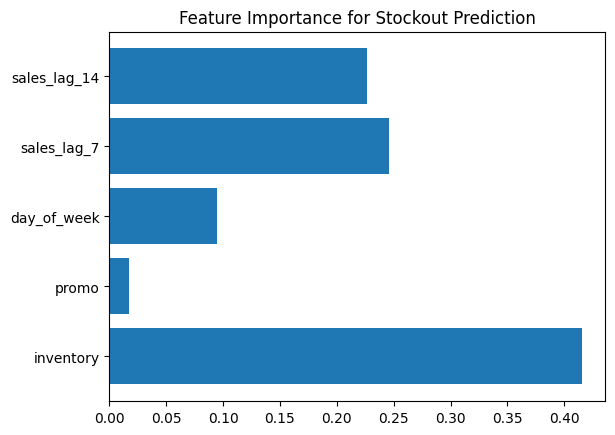

In [20]:
import matplotlib.pyplot as plt
importance= model.feature_importances_
plt.barh(features,importance)
plt.title("Feature Importance for Stockout Prediction")
plt.show()